In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load the stock market dataset

df = pd.read_csv("/content/Merged_Stock_Market_Dataset.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort data correctly for each stock
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# Display dataset information
print("Dataset Shape:", df.shape)
print("Number of Tickers:", df["Ticker"].nunique())

df.head()

Dataset Shape: (177728, 10)
Number of Tickers: 70


,Date,Ticker,Company,Open,High,Low,Close,Adj Close,Volume,Source
0,2016-09-20,6758.T,6758.T,655.400024,674.799988,654.799988,664.000000,623.805298,32968000.0,Yahoo Finance Worldwide
1,2016-09-21,6758.T,6758.T,663.000000,674.799988,655.000000,674.599976,633.763489,35469500.0,Yahoo Finance Worldwide
2,2016-09-23,6758.T,6758.T,680.000000,685.799988,678.000000,680.000000,638.836609,31894000.0,Yahoo Finance Worldwide
3,2016-09-26,6758.T,6758.T,679.599976,682.000000,673.400024,676.200012,635.266724,20983500.0,Yahoo Finance Worldwide
4,2016-09-27,6758.T,6758.T,660.000000,676.000000,660.000000,675.599976,634.702942,30895500.0,Yahoo Finance Worldwide


In [ ]:
# Remove duplicate records

df = df.drop_duplicates(
    subset=["Ticker", "Date"]
).reset_index(drop=True)

# Replace invalid volume values with NaN
df["Volume"] = df["Volume"].replace(0, np.nan)

# Fill volume values using the previous/next valid value within each ticker
df["Volume"] = (
    df.groupby("Ticker")["Volume"]
    .transform(lambda x: x.ffill().bfill())
)

# Check missing values
print("Missing values:")
print(df.isna().sum())

Missing values:
Date         0
Ticker       0
Company      0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Source       0
dtype: int64


In [ ]:
# Previous closing price features

for lag in [1, 3, 5, 10]:
    df[f"Close_Lag_{lag}"] = (
        df.groupby("Ticker")["Close"].shift(lag)
    )

# Daily return
df["Daily_Return"] = (
    df.groupby("Ticker")["Close"].pct_change()
)

# Moving averages
for window in [5, 10, 20]:
    df[f"MA_{window}"] = (
        df.groupby("Ticker")["Close"]
        .transform(lambda x: x.rolling(window).mean())
    )

# 5-day volatility
df["Volatility_5"] = (
    df.groupby("Ticker")["Daily_Return"]
    .transform(lambda x: x.rolling(5).std())
)

# Volume percentage change
df["Volume_Change"] = (
    df.groupby("Ticker")["Volume"].pct_change()
)

In [ ]:
# Create next-day closing price as the target

df["Target"] = (
    df.groupby("Ticker")["Close"].shift(-1)
)

print(
    df[
        ["Ticker", "Date", "Close", "Target"]
    ].head(10)
)

   Ticker       Date       Close      Target
0  6758.T 2016-09-20  664.000000  674.599976
1  6758.T 2016-09-21  674.599976  680.000000
2  6758.T 2016-09-23  680.000000  676.200012
3  6758.T 2016-09-26  676.200012  675.599976
4  6758.T 2016-09-27  675.599976  673.599976
5  6758.T 2016-09-28  673.599976  676.599976
6  6758.T 2016-09-29  676.599976  658.599976
7  6758.T 2016-09-30  658.599976  667.000000
8  6758.T 2016-10-03  667.000000  674.200012
9  6758.T 2016-10-04  674.200012  678.400024


In [ ]:
# Select features for Lasso Regression

features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",
    "Close_Lag_1",
    "Close_Lag_3",
    "Close_Lag_5",
    "Close_Lag_10",
    "MA_5",
    "MA_10",
    "MA_20",
    "Daily_Return",
    "Volatility_5",
    "Volume_Change"
]

X = df[features].copy()
y = df["Target"].copy()

print("Number of Features:", len(features))

Number of Features: 16


In [ ]:
# Replace infinity values with NaN

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows containing missing values
valid_rows = X.notna().all(axis=1) & y.notna()

X = X.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True)

# Keep matching date and ticker information
model_info = df.loc[
    valid_rows,
    ["Date", "Ticker"]
].reset_index(drop=True)

print("Final dataset shape:", X.shape)
print("Infinity values:", np.isinf(X).sum().sum())
print("Missing values:", X.isna().sum().sum())

Final dataset shape: (176328, 16)
Infinity values: 0
Missing values: 0


In [ ]:
# Use 80% of the historical data for training
# and the latest 20% for testing

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 141062
Testing samples: 35266


In [ ]:
# Standardize features before Lasso Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


In [ ]:
# Create Lasso Regression model

lasso = Lasso(
    alpha=0.001,
    max_iter=10000
)

# Train the model

lasso.fit(
    X_train_scaled,
    y_train
)

print("Lasso Regression trained successfully")

Lasso Regression trained successfully


In [ ]:
# Predict next-day closing prices

y_pred = lasso.predict(
    X_test_scaled
)

print("Predictions generated successfully")

# Display first 10 predictions

prediction_preview = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

prediction_preview

Predictions generated successfully


,Actual,Predicted
0,3375.5,3480.471927
1,3346.0,3386.198898
2,3384.5,3351.705234
3,3196.0,3363.626599
4,3274.5,3268.833603
5,3276.0,3292.281946
6,3299.5,3265.503269
7,3293.5,3286.842393
8,3307.5,3299.370396
9,3252.5,3326.514519


In [ ]:
# Calculate evaluation metrics

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

# Display results

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

LASSO REGRESSION RESULTS
MAE  : 12.7313
MSE  : 5229.1188
RMSE : 72.3126
R²   : 0.9972


In [ ]:
# Create prediction results table

results = model_info.iloc[split_index:].copy()

results["Actual_Close"] = y_test.values
results["Predicted_Close"] = y_pred

results["Error"] = (
    results["Actual_Close"]
    - results["Predicted_Close"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

# Display results

results.head(20)

,Date,Ticker,Actual_Close,Predicted_Close,Error,Absolute_Error
141062,2026-04-13,SHEL.L,3375.5,3480.471927,-104.971927,104.971927
141063,2026-04-14,SHEL.L,3346.0,3386.198898,-40.198898,40.198898
141064,2026-04-15,SHEL.L,3384.5,3351.705234,32.794766,32.794766
141065,2026-04-16,SHEL.L,3196.0,3363.626599,-167.626599,167.626599
141066,2026-04-17,SHEL.L,3274.5,3268.833603,5.666397,5.666397
141067,2026-04-20,SHEL.L,3276.0,3292.281946,-16.281946,16.281946
141068,2026-04-21,SHEL.L,3299.5,3265.503269,33.996731,33.996731
141069,2026-04-22,SHEL.L,3293.5,3286.842393,6.657607,6.657607
141070,2026-04-23,SHEL.L,3307.5,3299.370396,8.129604,8.129604
141071,2026-04-24,SHEL.L,3252.5,3326.514519,-74.014519,74.014519


In [ ]:
# ==========================================
# NEXT DAY STOCK PRICE PREDICTION
# ==========================================

# Enter stock details

ticker = input("Enter Company/Ticker: ")

open_price = float(input("Enter Open: "))
high_price = float(input("Enter High: "))
low_price = float(input("Enter Low: "))
close_price = float(input("Enter Close: "))
adj_close = float(input("Enter Adj Close: "))
volume = float(input("Enter Volume: "))

# ------------------------------------------
# Create user input
# ------------------------------------------

user_input = pd.DataFrame({
    "Open": [open_price],
    "High": [high_price],
    "Low": [low_price],
    "Close": [close_price],
    "Adj Close": [adj_close],
    "Volume": [volume]
})

# ------------------------------------------
# Features used by the model
# ------------------------------------------

features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

# ------------------------------------------
# Clean dataset
# ------------------------------------------

X = df[features].replace(
    [np.inf, -np.inf],
    np.nan
)

y = df["Target"]

valid = X.notna().all(axis=1) & y.notna()

X = X[valid]
y = y[valid]

# ------------------------------------------
# Train Lasso model
# ------------------------------------------

split = int(len(X) * 0.80)

X_train = X.iloc[:split]
y_train = y.iloc[:split]

# Scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Create and train Lasso

lasso = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------
# Scale user input
# ------------------------------------------

user_input_scaled = scaler.transform(
    user_input[features]
)

# ------------------------------------------
# Predict next-day Close
# ------------------------------------------

predicted_price = lasso.predict(
    user_input_scaled
)[0]

# ------------------------------------------
# Display result
# ------------------------------------------

print("\n" + "=" * 45)
print("NEXT DAY STOCK PRICE PREDICTION")
print("=" * 45)

print("Company/Ticker:", ticker)

print("-" * 45)

print(f"Predicted Next-Day Close: {predicted_price:.2f}")

print("=" * 45)

Enter Company/Ticker: WIPRO.NS
Enter Open: 170.02
Enter High: 170.89
Enter Low: 166.11
Enter Close: 166.89
Enter Adj Close: 166.89
Enter Volume: 11030339

NEXT DAY STOCK PRICE PREDICTION
Company/Ticker: WIPRO.NS
---------------------------------------------
Predicted Next-Day Close: 168.09


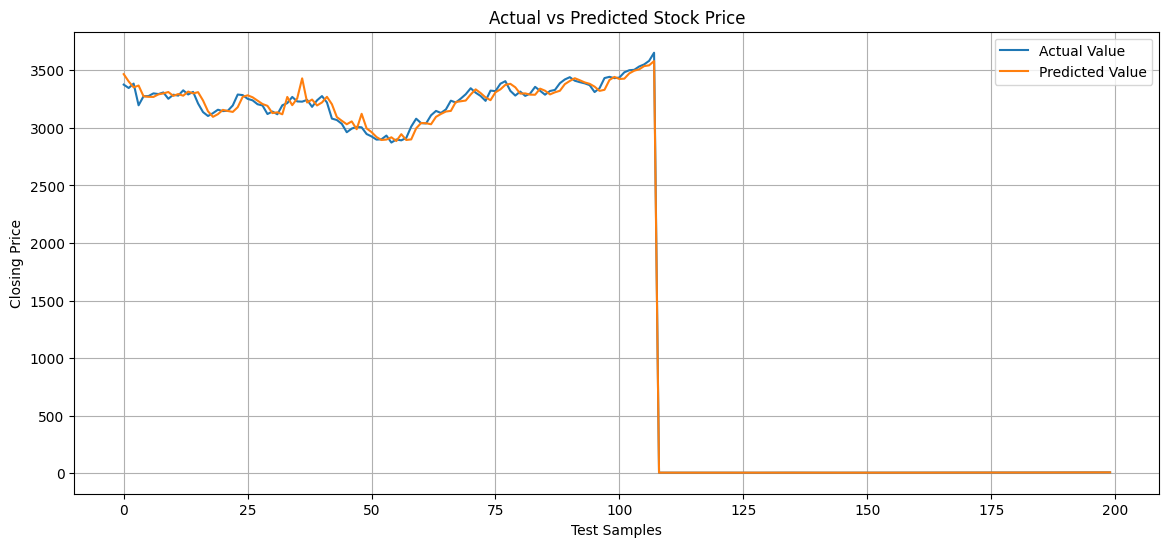

In [ ]:
# ==========================================
# ACTUAL VS PREDICTED GRAPH
# ==========================================

# Features used by current Lasso model

features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

# Create test data using the same 6 features

X_test_graph = X_test[features].copy()

# Scale test data using the current scaler

X_test_graph_scaled = scaler.transform(
    X_test_graph
)

# Predict test values

y_pred = lasso.predict(
    X_test_graph_scaled
)

# Plot Actual vs Predicted

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:200],
    label="Actual Value"
)

plt.plot(
    y_pred[:200],
    label="Predicted Value"
)

plt.xlabel("Test Samples")
plt.ylabel("Closing Price")

plt.title(
    "Actual vs Predicted Stock Price"
)

plt.legend()

plt.grid(True)

plt.show()